In [2]:
import yaml

def read_text_file(file_path):
    with open(file_path, 'r') as file:
        lines = file.readlines()
    return [line.strip() for line in lines if line.strip()]

def write_yaml_file(file_path, augmentations):
    data = {'augmentations': augmentations}
    with open(file_path, 'w') as file:
        yaml.dump(data, file, default_flow_style=False)

base_path = '/home/srikapan/workspace/VLMEvalKit/aug'
input_file_path = f'{base_path}/ip_selected.txt'  # Replace with your input file path
output_file_path = f'{base_path}/config_selected.yaml'  # Replace with your output file path

lines = read_text_file(input_file_path)

augmentations = []
for line in lines:
    augmentations.append({
        'name': line,
        'params': {'p': 1}
    })

    write_yaml_file(output_file_path, augmentations)

In [51]:
import os
os.environ['ALBUMENTATIONS_DISABLE_VERSION_CHECK'] = '1'

import yaml
import cv2
import numpy as np
from albumentations import Compose
from albumentations import *

def resize_image(image, size=(60, 60)):
    return cv2.resize(image, size)

def load_config(config_path):
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def get_augmentations(config):
    augmentations = {}
    for aug in config['augmentations']:
        aug_name = aug['name']
        aug_params = aug['params']
        augmentation = globals()[aug_name](**aug_params)
        augmentations[aug_name] = augmentation
    return augmentations

def read_images(input_dir):
    images = []
    for filename in os.listdir(input_dir):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(input_dir, filename)
            image = resize_image(cv2.imread(img_path))
            images.append(image)
    return images

def create_collage(images, aug_images, num_aug_image):
    rows = len(images)
    cols = num_aug_image + 1  # Including the original image
    height, width, _ = images[0].shape
    collage = np.zeros((rows * height, cols * width, 3), dtype=np.uint8)

    for i in range(rows):
        collage[i*height:(i+1)*height, 0:width] = images[i]  # Original image
        for j, aug_img in enumerate(aug_images[i*num_aug_image: (i+1)*num_aug_image]):
            collage[i*height:(i+1)*height, (j+1)*width:(j+2)*width] = aug_img  # Augmented images
    return collage

base_path = '.'
config_path = f'{base_path}/config_pixel.yaml'
input_dir = f'{base_path}/images'
output_path = f'{base_path}/collage_pixel.jpg'
config = load_config(config_path)
augmentations = get_augmentations(config)
images = read_images(input_dir)
augmented_images = []
for image in images:
    for idx, (aug_name, augmentation) in enumerate(augmentations.items()):
        augmented = augmentation(image=image)['image']
        font = cv2.FONT_HERSHEY_SIMPLEX
        org = (15, 15)
        fontScale = 0.5
        color = (255, 0, 0)
        thickness = 1
        augmented = cv2.putText(augmented, f'{idx}', org, font,
                   fontScale, color, thickness, cv2.LINE_AA)
        augmented_images.append(augmented)
collage = create_collage(images, augmented_images, len(augmentations))
cv2.imwrite(output_path, collage)


aug_base_path = '.'
config_path = f'{base_path}/config_spatial.yaml'
input_dir = f'{base_path}/images'
output_path = f'{base_path}/collage_spatial.jpg'
config = load_config(config_path)
augmentations = get_augmentations(config)
images = read_images(input_dir)
augmented_images = []
for image in images:
    for idx, (aug_name, augmentation) in enumerate(augmentations.items()):
        augmented = augmentation(image=image)['image']
        font = cv2.FONT_HERSHEY_SIMPLEX
        org = (15, 15)
        fontScale = 0.5
        color = (255, 0, 0)
        thickness = 1
        augmented = cv2.putText(augmented, f'{idx}', org, font,
                   fontScale, color, thickness, cv2.LINE_AA)
        augmented_images.append(augmented)
collage = create_collage(images, augmented_images, len(augmentations))
cv2.imwrite(output_path, collage)

True

In [8]:
import yaml
from PIL import Image
from albumentations import *

def load_config(config_path):
    with open(config_path, 'r') as file:
        config = yaml.safe_load(file)
    return config

def get_augmentations(config):
    augmentations = []
    for aug in config['augmentations']:
        aug_name = aug['name']
        aug_params = aug['params']
        augmentation = globals()[aug_name](**aug_params)
        augmentations.append(augmentation)
    return augmentations

config_path = '/home/srikapan/workspace/VLMEvalKit/data/config_spatial.yaml'
config = load_config(config_path)

image_path = '/home/srikapan/workspace/VLMEvalKit/data/images/apple.jpg'
image = Image.open(image_path).convert('RGB')


/home/srikapan/anaconda3/envs/VLMEvalKit/lib/python3.10/site-packages/albumentations/core/validation.py:45: UserWarning: This augmenter is very slow. Try to use ``ElasticTransformation`` instead, which is at least 10x faster.
  original_init(self, **validated_kwargs)


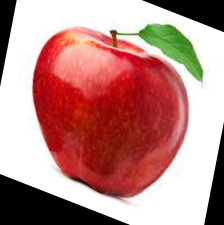

In [9]:
transforms = get_augmentations(config)
transform = transforms[0]
if transform:
    augmented_image_np = transform(image=np.array(image))['image']
    aug_image = Image.fromarray(augmented_image_np)

aug_image